# Freight Rate Prediction
This notebook contains the exploratory data analysis, data cleaning,
feature engineering, model comparison, validation, and final prediction
generation for the freight rate prediction assessment.

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Data loading

In [37]:
pd.set_option("display.max_columns", None)
df = pd.read_csv("../data/train-test.csv")
print("Shape:", df.shape)
df.head()

Shape: (48000, 14)


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


In [39]:
df.isnull().sum()

load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          300
date              0
market_index    374
quote_signal      0
posted_rate       0
dtype: int64

In [40]:
df.describe()

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,market_index,quote_signal,posted_rate
count,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,47700.000000,47626.000000,48000.000000,48000.000000
mean,35.647545,-90.928964,35.641175,-90.857310,1135.856654,31028.844004,1.083387,2.062468,2373.980682
std,4.315285,13.482431,4.317199,13.476589,728.564416,9391.440620,0.168091,0.291391,1486.493245
min,28.357650,-121.698490,28.357650,-121.698490,70.000000,-47500.000000,0.676390,0.692280,57.220000
25%,31.986910,-98.400590,31.986910,-98.400590,550.400000,25800.000000,0.949670,1.891030,1251.555000
50%,35.294790,-88.089150,35.294790,-87.528710,953.300000,31436.500000,1.055800,2.055750,2030.760000
75%,39.411040,-83.285060,39.411040,-83.285060,1645.525000,37018.000000,1.219590,2.221685,3330.750000
max,44.302960,-69.500000,44.302960,-69.500000,3439.800000,47500.000000,1.467780,3.610350,25533.000000


In [41]:
df['posted_rate'].describe()

count    48000.000000
mean      2373.980682
std       1486.493245
min         57.220000
25%       1251.555000
50%       2030.760000
75%       3330.750000
max      25533.000000
Name: posted_rate, dtype: float64

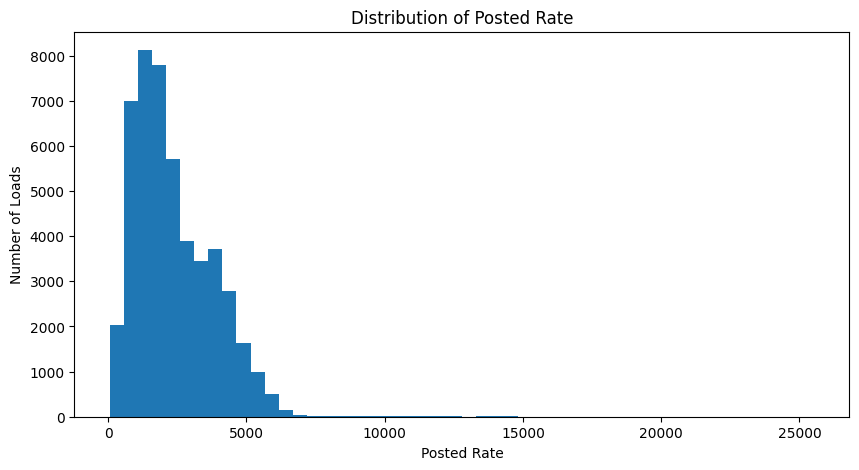

In [42]:
plt.figure(figsize=(10, 5))

plt.hist(df["posted_rate"], bins=50)

plt.xlabel("Posted Rate")
plt.ylabel("Number of Loads")
plt.title("Distribution of Posted Rate")

plt.show()

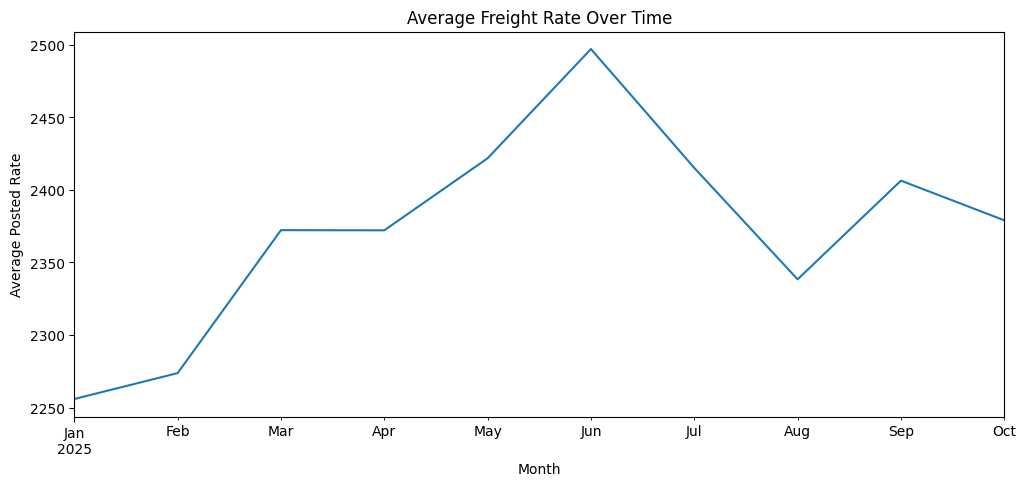

In [43]:
df["date"] = pd.to_datetime(df["date"])

monthly = (
    df.groupby(df["date"].dt.to_period("M"))["posted_rate"].mean()
)

monthly.plot(figsize=(12, 5))

plt.xlabel("Month")
plt.ylabel("Average Posted Rate")
plt.title("Average Freight Rate Over Time")

plt.show()

In [44]:
df[df['weight']<0]['weight'].describe()

count      292.000000
mean    -31724.195205
std       8262.536326
min     -47500.000000
25%     -37284.250000
50%     -31821.500000
75%     -25928.500000
max      -5000.000000
Name: weight, dtype: float64

In [45]:
df[df['weight']<0]['posted_rate'].describe()

count      292.000000
mean      2389.786233
std       1641.761285
min        247.370000
25%       1257.410000
50%       1994.960000
75%       3185.257500
max      14561.210000
Name: posted_rate, dtype: float64

In [46]:
df.groupby(df["weight"] < 0)["posted_rate"].mean()

weight
False    2373.883943
True     2389.786233
Name: posted_rate, dtype: float64

In [47]:
negative_weight = df[df["weight"] < 0]

print("Negative weight rows:", len(negative_weight))
print("Percentage:", len(negative_weight) / len(df) * 100)

Negative weight rows: 292
Percentage: 0.6083333333333333


In [48]:
df_clean = df[(df["weight"] >= 0) | (df["weight"].isna())].copy()

print("Original:", df.shape)
print("After removing negative weights:", df_clean.shape)

Original: (48000, 14)
After removing negative weights: (47708, 14)


In [49]:
numeric_cols = df_clean.select_dtypes(include=np.number).columns

for col in numeric_cols:
    print(f"\n{col}")
    print("Missing:", df_clean[col].isna().sum())
    print("Negative:", (df_clean[col] < 0).sum())


pickup_lat
Missing: 0
Negative: 0

pickup_lon
Missing: 0
Negative: 47708

delivery_lat
Missing: 0
Negative: 0

delivery_lon
Missing: 0
Negative: 47708

distance
Missing: 0
Negative: 0

weight
Missing: 300
Negative: 0

market_index
Missing: 371
Negative: 0

quote_signal
Missing: 0
Negative: 0

posted_rate
Missing: 0
Negative: 0


In [50]:
df_clean.isna().sum()

load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          300
date              0
market_index    371
quote_signal      0
posted_rate       0
dtype: int64

In [51]:
missing = df_clean.isna().sum()

missing_pct = (missing / len(df_clean)) * 100

pd.DataFrame({
    "missing_count": missing,
    "missing_percentage": missing_pct
}).sort_values("missing_count", ascending=False)

,missing_count,missing_percentage
market_index,371,0.777647
weight,300,0.628825
delivery,0,0.000000
pickup_lat,0,0.000000
load_id,0,0.000000
pickup,0,0.000000
delivery_lat,0,0.000000
pickup_lon,0,0.000000
distance,0,0.000000
delivery_lon,0,0.000000


In [52]:
monthly_counts = (
    df_clean
    .groupby(df_clean["date"].dt.to_period("M"))
    .size()
)

print(monthly_counts)

date
2025-01    4887
2025-02    4307
2025-03    4996
2025-04    4794
2025-05    4873
2025-06    4753
2025-07    4890
2025-08    4744
2025-09    4644
2025-10    4820
Freq: M, dtype: int64


In [53]:
train_df = df_clean[df_clean["date"] < "2025-10-01"].copy()

val_df = df_clean[df_clean["date"] >= "2025-10-01"].copy()

print("Training shape:", train_df.shape)
print("Validation shape:", val_df.shape)

print(
    "Training period:",
    train_df["date"].min(),
    "to",
    train_df["date"].max()
)

print(
    "Validation period:",
    val_df["date"].min(),
    "to",
    val_df["date"].max()
)

Training shape: (42888, 14)
Validation shape: (4820, 14)
Training period: 2025-01-01 00:00:00 to 2025-09-30 00:00:00
Validation period: 2025-10-01 00:00:00 to 2025-10-31 00:00:00


In [54]:
target = "posted_rate"

X_train = train_df.drop(columns=[target])
y_train = train_df[target]

X_val = val_df.drop(columns=[target])
y_val = val_df[target]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_train: (42888, 13)
y_train: (42888,)
X_val: (4820, 13)
y_val: (4820,)


In [55]:
X_train = X_train.drop(columns=["load_id"])
X_val = X_val.drop(columns=["load_id"])
print(X_train.shape)
print(X_val.shape)

(42888, 12)
(4820, 12)


In [56]:
def add_date_features(df):
    df = df.copy()
    
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["day_of_week"] = df["date"].dt.dayofweek
    
    df = df.drop(columns=["date"])
    
    return df

In [57]:
X_train_processed = add_date_features(X_train)
X_val_processed = add_date_features(X_val)

In [58]:
print(X_train_processed.head())
print(X_train_processed.dtypes)

         pickup      delivery  pickup_lat  pickup_lon  delivery_lat  \
0      Richmond     Baltimore    38.09122   -76.78906      38.16908   
1      Richmond  Philadelphia    38.09122   -76.78906      39.22317   
2  Philadelphia     Green Bay    39.22317   -72.96710      44.30296   
3      Hartford       Atlanta    39.55328   -72.18051      34.84933   
4        Dallas     Nashville    31.83025   -94.38343      35.29479   

   delivery_lon  distance equipment   weight  market_index  quote_signal  \
0     -72.74564     274.3   Dry Van  30658.0       0.95684       2.39595   
1     -72.96710     280.5    Reefer  17555.0       0.97623       2.43355   
2     -87.52871     967.8   Dry Van  31721.0       1.00971       1.84491   
3     -86.28940     965.4   Dry Van  32333.0       0.94518       1.87712   
4     -88.08915     541.9    Reefer  35183.0       0.98480       2.56300   

   year  month  day  day_of_week  
0  2025      1    1            2  
1  2025      1    1            2  
2  2025    

In [59]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

baseline_prediction = y_train.median()

baseline_preds = np.full(
    len(y_val),
    baseline_prediction
)

baseline_mae = mean_absolute_error(y_val, baseline_preds)
baseline_rmse = np.sqrt(mean_squared_error(y_val, baseline_preds))

print("Baseline prediction:", baseline_prediction)
print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)

Baseline prediction: 2029.69
Baseline MAE: 1146.9757821576763
Baseline RMSE: 1569.0477252994326


In [60]:
def add_date_features(df):
    df = df.copy()

    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["day_of_week"] = df["date"].dt.dayofweek

    df = df.drop(columns=["date"])

    return df

In [61]:
X_train_processed = add_date_features(X_train)
X_val_processed = add_date_features(X_val)

print("Training:", X_train_processed.shape)
print("Validation:", X_val_processed.shape)

Training: (42888, 15)
Validation: (4820, 15)


In [63]:
categorical_features = [
    "pickup",
    "delivery",
    "equipment"
]

numerical_features = [
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "year",
    "month",
    "day",
    "day_of_week"
]

In [64]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [65]:
from sklearn.ensemble import HistGradientBoostingRegressor

model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.08,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=42
)

In [66]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

In [67]:
model_pipeline.fit(
    X_train_processed,
    y_train
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [68]:
val_predictions = model_pipeline.predict(X_val_processed)

In [69]:
mae = mean_absolute_error(y_val, val_predictions)
rmse = np.sqrt(mean_squared_error(y_val, val_predictions))

print("Model MAE:", mae)
print("Model RMSE:", rmse)

Model MAE: 132.01283572452172
Model RMSE: 655.9348967840795


In [70]:
results = val_df[["load_id", "posted_rate"]].copy()

results["predicted_rate"] = val_predictions

results["error"] = (
    results["posted_rate"] - results["predicted_rate"]
)

results["absolute_error"] = results["error"].abs()

results.sort_values(
    "absolute_error",
    ascending=False
).head(10)

,load_id,posted_rate,predicted_rate,error,absolute_error
43539,TR-043540,17514.11,3752.901056,13761.208944,13761.208944
46213,TR-046214,17893.17,4343.715421,13549.454579,13549.454579
47298,TR-047299,19110.30,5998.745050,13111.554950,13111.554950
46516,TR-046517,14784.38,3671.325863,11113.054137,11113.054137
44267,TR-044268,14425.42,4273.263029,10152.156971,10152.156971
47536,TR-047537,15003.55,4899.732029,10103.817971,10103.817971
46366,TR-046367,14403.14,4392.775070,10010.364930,10010.364930
43302,TR-043303,13894.55,4456.098221,9438.451779,9438.451779
43384,TR-043385,11696.44,2406.717985,9289.722015,9289.722015
47586,TR-047587,11596.28,2938.400419,8657.879581,8657.879581


In [71]:
print(results["absolute_error"].describe())

count     4820.000000
mean       132.012836
std        642.579852
min          0.008808
25%         22.144371
50%         47.235161
75%         91.544239
max      13761.208944
Name: absolute_error, dtype: float64


In [72]:
print(
    df_clean[["quote_signal", "posted_rate"]]
    .corr()
)

              quote_signal  posted_rate
quote_signal      1.000000    -0.039844
posted_rate      -0.039844     1.000000


In [73]:
worst_loads = (
    results
    .sort_values("absolute_error", ascending=False)
    .head(10)
)

worst_ids = worst_loads["load_id"]

df_clean[df_clean["load_id"].isin(worst_ids)]

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
43302,TR-043303,Atlanta,Phoenix,34.84933,-86.28940,28.75668,-115.87725,2083.1,Reefer,40335.0,2025-10-01,0.90740,1.94613,13894.55
43384,TR-043385,Lexington,Lubbock,36.99152,-84.99876,29.87534,-99.85456,1187.0,Dry Van,25359.0,2025-10-02,0.95849,2.17408,11696.44
43539,TR-043540,Milwaukee,Bakersfield,39.62180,-88.48008,33.28832,-116.67935,1893.0,Dry Van,30760.0,2025-10-03,1.08079,2.22972,17514.11
44267,TR-044268,Albany,Albuquerque,43.96975,-71.05842,35.39918,-109.59792,2492.6,Dry Van,25513.0,2025-10-08,1.05590,2.38846,14425.42
46213,TR-046214,Columbia,Tucson,34.63570,-83.28506,30.92733,-113.23037,2023.4,Flatbed,34710.0,2025-10-20,0.89822,2.06797,17893.17
46366,TR-046367,Bakersfield,Columbia,33.28832,-116.67935,34.63570,-83.28506,2251.9,Dry Van,40729.0,2025-10-21,0.94743,2.19163,14403.14
46516,TR-046517,Toledo,Albuquerque,41.97663,-84.45902,35.39918,-109.59792,1684.3,Reefer,31536.0,2025-10-22,0.98632,2.05917,14784.38
47298,TR-047299,Boston,Bakersfield,39.27463,-69.50000,33.28832,-116.67935,2979.1,Reefer,30585.0,2025-10-27,0.86501,2.09472,19110.30
47536,TR-047537,Los Angeles,Richmond,28.56624,-116.70249,38.09122,-76.78906,2782.4,Dry Van,25730.0,2025-10-29,1.03410,2.39203,15003.55
47586,TR-047587,Corpus Christi,Las Vegas,28.61374,-95.89569,33.22353,-115.24994,1383.3,Flatbed,18645.0,2025-10-29,1.01713,2.02448,11596.28


In [74]:
df_clean.sort_values(
    "posted_rate",
    ascending=False
).head(20)

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
12184,TR-012185,Bakersfield,Hartford,33.28832,-116.67935,39.55328,-72.18051,2829.8,Dry Van,33153.0,2025-03-19,1.16556,1.83188,25533.00
37764,TR-037765,Phoenix,Syracuse,28.75668,-115.87725,42.80915,-76.89973,2810.9,Dry Van,33674.0,2025-08-27,1.04877,2.16284,24294.98
1466,TR-001467,Los Angeles,Syracuse,28.56624,-116.70249,42.80915,-76.89973,2786.0,Reefer,30322.0,2025-01-10,0.98678,1.85370,24140.21
17371,TR-017372,Reno,Philadelphia,39.54838,-118.64843,39.22317,-72.96710,2777.6,Reefer,33158.0,2025-04-20,1.15070,2.15601,23662.71
26235,TR-026236,Charleston,Phoenix,34.15334,-79.74475,28.75668,-115.87725,2552.5,Dry Van,25665.0,2025-06-15,1.20224,1.81289,23580.42
28219,TR-028220,Tucson,Raleigh,30.92733,-113.23037,35.37376,-77.47605,2423.3,Dry Van,30972.0,2025-06-27,1.32894,1.97112,22755.66
3353,TR-003354,Phoenix,Charleston,28.75668,-115.87725,34.15334,-79.74475,2527.9,Reefer,36840.0,2025-01-22,1.03241,2.07342,22534.65
40171,TR-040172,Montgomery,Fresno,31.37602,-86.10743,33.07921,-119.79528,2283.4,Dry Van,32447.0,2025-09-11,0.98502,1.93645,20361.89
40096,TR-040097,Baltimore,Oklahoma City,38.16908,-72.74564,31.88294,-98.58097,1760.3,Reefer,29521.0,2025-09-11,1.00464,2.28753,20132.37
47298,TR-047299,Boston,Bakersfield,39.27463,-69.50000,33.28832,-116.67935,2979.1,Reefer,30585.0,2025-10-27,0.86501,2.09472,19110.30


In [75]:
high_rate = df_clean[df_clean["posted_rate"] > 10000]

print("Loads above $10,000:", len(high_rate))
print("Percentage:", len(high_rate) / len(df_clean) * 100)

high_rate.describe()

Loads above $10,000: 102
Percentage: 0.2138006204410162


,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,date,market_index,quote_signal,posted_rate
count,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102,102.000000,102.000000,102.000000
mean,34.871107,-95.028761,34.769031,-94.851992,1879.498039,32094.872549,2025-06-17 11:45:52.941176576,1.093625,2.038147,13850.694608
min,28.566240,-121.698490,28.357650,-119.795280,1040.000000,16292.000000,2025-01-04 00:00:00,0.746010,1.686370,10036.500000
25%,31.483120,-112.500852,31.804420,-113.230370,1422.025000,26746.250000,2025-04-20 12:00:00,0.965490,1.927045,11285.560000
50%,33.806140,-90.506345,33.299535,-92.318880,1849.700000,31506.000000,2025-06-25 12:00:00,1.057495,2.000665,12559.865000
75%,38.489762,-84.616417,39.048795,-82.420903,2216.525000,36819.250000,2025-08-26 00:00:00,1.241845,2.152977,14896.955000
max,44.302960,-69.500000,43.969750,-69.500000,3183.800000,47500.000000,2025-10-29 00:00:00,1.425710,2.472400,25533.000000
std,4.559622,16.215892,4.325413,16.532600,547.789367,7368.012873,NaN,0.171155,0.180378,3678.484143


In [76]:
print("Training target:")
print(y_train.describe())

print("\nOctober validation target:")
print(y_val.describe())

Training target:
count    42888.000000
mean      2373.081664
std       1480.517707
min         57.220000
25%       1253.857500
50%       2029.690000
75%       3334.245000
max      25533.000000
Name: posted_rate, dtype: float64

October validation target:
count     4820.000000
mean      2381.022566
std       1529.366357
min        104.380000
25%       1233.817500
50%       2037.795000
75%       3305.760000
max      19110.300000
Name: posted_rate, dtype: float64


In [77]:
print(
    high_rate["quote_signal"].describe()
)

count    102.000000
mean       2.038147
std        0.180378
min        1.686370
25%        1.927045
50%        2.000665
75%        2.152977
max        2.472400
Name: quote_signal, dtype: float64


In [78]:
print(
    df_clean[df_clean["posted_rate"] <= 10000]["quote_signal"].describe()
)

count    47606.000000
mean         2.062646
std          0.291538
min          0.692280
25%          1.891060
50%          2.055995
75%          2.221938
max          3.610350
Name: quote_signal, dtype: float64


In [79]:
df_clean["rate_per_mile"] = (
    df_clean["posted_rate"] / df_clean["distance"]
)

In [80]:
print(
    high_rate[
        ["distance", "posted_rate"]
    ]
)

       distance  posted_rate
469      2154.3     10854.69
1466     2786.0     24140.21
1949     2794.2     13918.00
2030     1247.6     10270.54
2221     1166.1     11210.34
...         ...          ...
46366    2251.9     14403.14
46516    1684.3     14784.38
47298    2979.1     19110.30
47536    2782.4     15003.55
47586    1383.3     11596.28

[102 rows x 2 columns]


In [83]:
df_clean["rate_per_mile"] = (
    df_clean["posted_rate"] / df_clean["distance"]
)

high_rate = df_clean[df_clean["posted_rate"] > 10000]

print(high_rate["rate_per_mile"].describe())

count    102.000000
mean       7.674646
std        1.772739
min        4.215274
25%        6.282354
50%        7.965019
75%        9.025161
max       11.436897
Name: rate_per_mile, dtype: float64


In [82]:
route_counts = (
    high_rate
    .groupby(["pickup", "delivery"])
    .size()
    .sort_values(ascending=False)
)

print(route_counts.head(20))

pickup       delivery      
Phoenix      Jacksonville      2
Los Angeles  Mobile            2
Albany       Albuquerque       1
             Baton Rouge       1
Albuquerque  Madison           1
             Milwaukee         1
Atlanta      Fresno            1
             Los Angeles       1
             Phoenix           1
Bakersfield  Buffalo           1
             Columbia          1
             Hartford          1
Baltimore    Oklahoma City     1
             Reno              1
Baton Rouge  Philadelphia      1
             Salt Lake City    1
Boston       Bakersfield       1
             Jacksonville      1
             Nashville         1
             Phoenix           1
dtype: int64


In [84]:
print("Unique routes:", 
      train_df[["pickup", "delivery"]].drop_duplicates().shape[0])

Unique routes: 4008


In [85]:
route_counts = (
    train_df
    .groupby(["pickup", "delivery"])
    .size()
    .sort_values(ascending=False)
)

print(route_counts.head(20))

pickup         delivery     
Phoenix        Shreveport       38
Richmond       Phoenix          37
Lexington      Atlanta          36
Columbia       Oklahoma City    35
Shreveport     Hartford         35
Oklahoma City  Columbia         34
               Atlanta          34
Columbia       Montgomery       34
Lexington      Cincinnati       34
Fort Wayne     Cincinnati       34
               Philadelphia     33
               Bakersfield      33
               Hartford         33
Bakersfield    Hartford         32
               Fort Wayne       32
Nashville      Baton Rouge      32
Grand Rapids   Mobile           32
Oklahoma City  Mobile           32
               Nashville        32
San Antonio    Fort Wayne       32
dtype: int64


In [86]:
X_train_route = X_train_processed.copy()
X_val_route = X_val_processed.copy()

X_train_route["route"] = (
    X_train_route["pickup"] + "_" +
    X_train_route["delivery"]
)

X_val_route["route"] = (
    X_val_route["pickup"] + "_" +
    X_val_route["delivery"]
)

In [87]:
print(X_train_route["route"].nunique())

4008


In [88]:
categorical_features_route = [
    "pickup",
    "delivery",
    "equipment",
    "route"
]

numerical_features_route = [
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "year",
    "month",
    "day",
    "day_of_week"
]

In [89]:
numeric_pipeline_route = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline_route = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor_route = ColumnTransformer([
    ("num", numeric_pipeline_route, numerical_features_route),
    ("cat", categorical_pipeline_route, categorical_features_route)
])

In [90]:
model_route = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.08,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=42
)

In [91]:
model_pipeline_route = Pipeline([
    ("preprocessor", preprocessor_route),
    ("model", model_route)
])

In [92]:
model_pipeline_route.fit(
    X_train_route,
    y_train
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [93]:
route_predictions = model_pipeline_route.predict(X_val_route)

In [94]:
route_mae = mean_absolute_error(
    y_val,
    route_predictions
)

route_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        route_predictions
    )
)

print("Route model MAE:", route_mae)
print("Route model RMSE:", route_rmse)

Route model MAE: 133.87400558056385
Route model RMSE: 657.412680682344


In [95]:
print("Model B did not improve validation performance, so route was not retained.")

Model B did not improve validation performance, so route was not retained.


In [96]:
X_train_cb = X_train.copy()
X_val_cb = X_val.copy()

X_train_cb["year"] = X_train_cb["date"].dt.year
X_train_cb["month"] = X_train_cb["date"].dt.month
X_train_cb["day"] = X_train_cb["date"].dt.day
X_train_cb["day_of_week"] = X_train_cb["date"].dt.dayofweek

X_val_cb["year"] = X_val_cb["date"].dt.year
X_val_cb["month"] = X_val_cb["date"].dt.month
X_val_cb["day"] = X_val_cb["date"].dt.day
X_val_cb["day_of_week"] = X_val_cb["date"].dt.dayofweek

X_train_cb = X_train_cb.drop(columns=["date"])
X_val_cb = X_val_cb.drop(columns=["date"])

In [97]:
categorical_features_cb = [
    "pickup",
    "delivery",
    "equipment"
]

for col in categorical_features_cb:
    X_train_cb[col] = X_train_cb[col].fillna("Missing").astype(str)
    X_val_cb[col] = X_val_cb[col].fillna("Missing").astype(str)

In [99]:
%pip install catboost


  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
  Using cached plotly-7.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached narwhals-2.26.0-py3-none-any.whl.metadata (15 kB)
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/100.2 MB 5.7 MB/s eta 0:00:18
    --------------------------------------- 2.1/100.2 MB 7.3 MB/s eta 0:00:14
   - -------------------------------------- 4.2/100.2 MB 8.1 MB/s eta 0:00:12
   -- ------------------------------------- 6.6/100.2 MB 9.2 MB/s eta 0:00:11
   --- ------------------------------------ 9.2/100.2 MB 10.0 MB/s eta 0:00:10
   ---- ----------------------------------- 12.3/100.2 MB 10.9 MB/s eta 0:00:09
   ------ --------------------------------- 16.3/100.2 MB 12.0 MB/s eta 0:00:07
   -------- ------------------------------- 20.4/100.2 MB 13.1 MB/s eta 0:00:07
   --------- ------------------------------ 24.4/100.2 MB 13.7 MB/s eta 0:00:06
   ---------- ------------

In [100]:
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

In [101]:
cat_model.fit(
    X_train_cb,
    y_train,
    cat_features=categorical_features_cb
)

0:	learn: 1422.7929774	total: 221ms	remaining: 1m 50s
100:	learn: 573.8897191	total: 10.2s	remaining: 40.3s
200:	learn: 562.8670417	total: 20.1s	remaining: 29.9s
300:	learn: 553.8908478	total: 27.5s	remaining: 18.2s
400:	learn: 544.3763167	total: 34.7s	remaining: 8.56s
499:	learn: 536.8623431	total: 44s	remaining: 0us


CatBoostRegressor(depth=8, iterations=500, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=100)

In [102]:
cat_predictions = cat_model.predict(X_val_cb)

In [103]:
cat_mae = mean_absolute_error(
    y_val,
    cat_predictions
)

cat_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        cat_predictions
    )
)

print("CatBoost MAE:", cat_mae)
print("CatBoost RMSE:", cat_rmse)

CatBoost MAE: 135.68844410959443
CatBoost RMSE: 654.1475120319734


In [104]:


final_df = df_clean.copy()

if "rate_per_mile" in final_df.columns:
    final_df = final_df.drop(columns=["rate_per_mile"])

X_final = final_df.drop(columns=["posted_rate"])
y_final = final_df["posted_rate"]

X_final = X_final.drop(columns=["load_id"])

X_final = add_date_features(X_final)

print(X_final.shape)
print(y_final.shape)

(47708, 15)
(47708,)


In [105]:
final_preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

final_model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.08,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=42
)

final_pipeline = Pipeline([
    ("preprocessor", final_preprocessor),
    ("model", final_model)
])

In [106]:
final_pipeline.fit(X_final, y_final)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [108]:
validation_df = pd.read_csv("../data/validation.csv")

print(validation_df.shape)
print(validation_df.head())
print(validation_df.columns)

(12000, 13)
     load_id         pickup     delivery  pickup_lat  pickup_lon  \
0  TE-000001    Baton Rouge       Mobile    30.50134   -92.65374   
1  TE-000002       Savannah  Los Angeles    33.60973   -82.29994   
2  TE-000003  San Francisco      Raleigh    35.19670  -121.69849   
3  TE-000004         Dayton  Los Angeles    39.87206   -85.62931   
4  TE-000005        Memphis  San Antonio    35.56802   -89.52871   

   delivery_lat  delivery_lon  distance equipment   weight        date  \
0      31.80442     -88.25195     331.4   Flatbed  19958.0  2025-11-01   
1      28.56624    -116.70249    2406.2    Reefer  34114.0  2025-11-01   
2      35.37376     -77.47605    2846.6   Dry Van  33435.0  2025-11-01   
3      28.56624    -116.70249    2261.6   Dry Van  25392.0  2025-11-01   
4      29.50969     -98.40059     800.4   Flatbed      NaN  2025-11-01   

   market_index  quote_signal  
0       0.90402       1.86388  
1       0.92851       1.86240  
2       0.88117       1.95480  
3     

In [112]:

validation_df["date"] = pd.to_datetime(validation_df["date"])


validation_ids = validation_df["load_id"].copy()

X_test = validation_df.drop(columns=["load_id"]).copy()

X_test = add_date_features(X_test)

print(X_test.shape)

(12000, 15)


In [113]:
validation_predictions = final_pipeline.predict(X_test)

print("Number of predictions:", len(validation_predictions))
print("First 10 predictions:", validation_predictions[:10])
print("Minimum prediction:", validation_predictions.min())

Number of predictions: 12000
First 10 predictions: [ 868.97196013 4987.62281031 5146.74392329 4307.20092384 1794.52263506
 4971.74704421 5133.71435649 2934.91942488 1118.4276161  1186.31841919]
Minimum prediction: 348.3736183404644


In [114]:
predictions_df = pd.DataFrame({
    "load_id": validation_ids,
    "predicted_rate": validation_predictions
})

print(predictions_df.head())
print(predictions_df.shape)

     load_id  predicted_rate
0  TE-000001      868.971960
1  TE-000002     4987.622810
2  TE-000003     5146.743923
3  TE-000004     4307.200924
4  TE-000005     1794.522635
(12000, 2)


In [116]:
predictions_df.to_csv("../result/validation_predictions.csv", index=False)

print("Saved successfully!")

Saved successfully!


In [117]:
december_dates = pd.date_range(
    start="2025-12-01",
    end="2025-12-31",
    freq="D"
)

december_df = pd.DataFrame({
    "pickup": "Lexington",
    "delivery": "Fort Wayne",
    "distance": 360.0,
    "equipment": "Dry Van",
    "weight": 32000.0,
    "date": december_dates
})

print(december_df.shape)
print(december_df.head())

(31, 6)
      pickup    delivery  distance equipment   weight       date
0  Lexington  Fort Wayne     360.0   Dry Van  32000.0 2025-12-01
1  Lexington  Fort Wayne     360.0   Dry Van  32000.0 2025-12-02
2  Lexington  Fort Wayne     360.0   Dry Van  32000.0 2025-12-03
3  Lexington  Fort Wayne     360.0   Dry Van  32000.0 2025-12-04
4  Lexington  Fort Wayne     360.0   Dry Van  32000.0 2025-12-05


In [ ]:

december_dates = pd.date_range(
    start="2025-12-01",
    end="2025-12-31",
    freq="D"
)

december_df = pd.DataFrame({
    "pickup": "Lexington",
    "delivery": "Fort Wayne",
    "distance": 360.0,
    "equipment": "Dry Van",
    "weight": 32000.0,
    "date": december_dates
})
pickup_info = (
    df_clean[df_clean["pickup"] == "Lexington"]
    [["pickup", "pickup_lat", "pickup_lon"]]
    .drop_duplicates("pickup")
)
delivery_info = (
    df_clean[df_clean["delivery"] == "Fort Wayne"]
    [["delivery", "delivery_lat", "delivery_lon"]]
    .drop_duplicates("delivery")
)
december_df = december_df.merge(
    pickup_info,
    on="pickup",
    how="left"
)

december_df = december_df.merge(
    delivery_info,
    on="delivery",
    how="left"
)

print(december_df)

       pickup    delivery  distance equipment   weight       date  pickup_lat  \
0   Lexington  Fort Wayne     360.0   Dry Van  32000.0 2025-12-01    36.99152   
1   Lexington  Fort Wayne     360.0   Dry Van  32000.0 2025-12-02    36.99152   
2   Lexington  Fort Wayne     360.0   Dry Van  32000.0 2025-12-03    36.99152   
3   Lexington  Fort Wayne     360.0   Dry Van  32000.0 2025-12-04    36.99152   
4   Lexington  Fort Wayne     360.0   Dry Van  32000.0 2025-12-05    36.99152   
5   Lexington  Fort Wayne     360.0   Dry Van  32000.0 2025-12-06    36.99152   
6   Lexington  Fort Wayne     360.0   Dry Van  32000.0 2025-12-07    36.99152   
7   Lexington  Fort Wayne     360.0   Dry Van  32000.0 2025-12-08    36.99152   
8   Lexington  Fort Wayne     360.0   Dry Van  32000.0 2025-12-09    36.99152   
9   Lexington  Fort Wayne     360.0   Dry Van  32000.0 2025-12-10    36.99152   
10  Lexington  Fort Wayne     360.0   Dry Van  32000.0 2025-12-11    36.99152   
11  Lexington  Fort Wayne   

In [120]:
print(december_df[
    ["pickup", "pickup_lat", "pickup_lon",
     "delivery", "delivery_lat", "delivery_lon"]
].drop_duplicates())

      pickup  pickup_lat  pickup_lon    delivery  delivery_lat  delivery_lon
0  Lexington    36.99152   -84.99876  Fort Wayne      41.31561     -85.36206


In [121]:
december_features = december_df.copy()

december_features = add_date_features(december_features)

print(december_features.shape)
print(december_features.columns)

(31, 13)
Index(['pickup', 'delivery', 'distance', 'equipment', 'weight', 'pickup_lat',
       'pickup_lon', 'delivery_lat', 'delivery_lon', 'year', 'month', 'day',
       'day_of_week'],
      dtype='object')


In [125]:
december_df["market_index"] = df_clean["market_index"].median()
december_df["quote_signal"] = df_clean["quote_signal"].median()

print(december_df.head())

      pickup    delivery  distance equipment   weight       date  pickup_lat  \
0  Lexington  Fort Wayne     360.0   Dry Van  32000.0 2025-12-01    36.99152   
1  Lexington  Fort Wayne     360.0   Dry Van  32000.0 2025-12-02    36.99152   
2  Lexington  Fort Wayne     360.0   Dry Van  32000.0 2025-12-03    36.99152   
3  Lexington  Fort Wayne     360.0   Dry Van  32000.0 2025-12-04    36.99152   
4  Lexington  Fort Wayne     360.0   Dry Van  32000.0 2025-12-05    36.99152   

   pickup_lon  delivery_lat  delivery_lon  market_index  quote_signal  
0   -84.99876      41.31561     -85.36206       1.05577      2.055905  
1   -84.99876      41.31561     -85.36206       1.05577      2.055905  
2   -84.99876      41.31561     -85.36206       1.05577      2.055905  
3   -84.99876      41.31561     -85.36206       1.05577      2.055905  
4   -84.99876      41.31561     -85.36206       1.05577      2.055905  


In [129]:
december_features = december_df.copy()

december_features = add_date_features(december_features)

december_predictions = final_pipeline.predict(december_features)

print("Number of predictions:", len(december_predictions))
print("Minimum:", december_predictions.min())
print("Maximum:", december_predictions.max())

Number of predictions: 31
Minimum: 875.978701065973
Maximum: 875.978701065973


In [131]:
december_output = december_df.copy()

december_output["predicted_rate"] = december_predictions

december_output.to_csv(
    "../result/december_predictions.csv",
    index=False
)

print(december_output.head())
print("Shape:", december_output.shape)

      pickup    delivery  distance equipment   weight       date  pickup_lat  \
0  Lexington  Fort Wayne     360.0   Dry Van  32000.0 2025-12-01    36.99152   
1  Lexington  Fort Wayne     360.0   Dry Van  32000.0 2025-12-02    36.99152   
2  Lexington  Fort Wayne     360.0   Dry Van  32000.0 2025-12-03    36.99152   
3  Lexington  Fort Wayne     360.0   Dry Van  32000.0 2025-12-04    36.99152   
4  Lexington  Fort Wayne     360.0   Dry Van  32000.0 2025-12-05    36.99152   

   pickup_lon  delivery_lat  delivery_lon  market_index  quote_signal  \
0   -84.99876      41.31561     -85.36206       1.05577      2.055905   
1   -84.99876      41.31561     -85.36206       1.05577      2.055905   
2   -84.99876      41.31561     -85.36206       1.05577      2.055905   
3   -84.99876      41.31561     -85.36206       1.05577      2.055905   
4   -84.99876      41.31561     -85.36206       1.05577      2.055905   

   predicted_rate  
0      875.978701  
1      875.978701  
2      875.978701  


In [133]:
december_score_file = december_output[
    ["pickup", "delivery", "distance", "equipment",
     "weight", "date", "predicted_rate"]
].copy()

december_score_file.to_csv(
    "../result/december_predictions.csv",
    index=False
)

print(december_score_file.shape)
print(december_score_file.columns.tolist())

(31, 7)
['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']
